# A Comprehensive Evaluation of Machine Learning Models for Skincare Ingredient Classification with Class Sparsity Reduction

This notebook trains and evaluates machine learning models to identify the different functions of cosmetic ingredients using the CosIng dataset. We compare models like Random Forest and XGBoost, then use a Class Sparsity Reduction Strategy to get the best results for skincare analysis.

In [1]:
import pandas as pd
import numpy as np
import os, re, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from scipy.sparse import hstack

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### Loading and Cleaning the Dataset
Loading the COSING Ingredients dataset and performing initial cleaning.

In [2]:
dataset_path = 'dataset_for_v2/COSING_Ingredients-Fragrance Inventory_v2.csv'
df = pd.read_csv(dataset_path)

# Mapping columns to standard names for logic consistency
df = df.rename(columns={'Chem/IUPAC Name / Description': 'Description', 'Function': 'Primary_Function'})

# Basic cleaning
df['Description'] = df['Description'].fillna('UNKNOWN')
df = df.dropna(subset=['Primary_Function'])
print(f'Dataset Loaded: {len(df)} ingredients')

Dataset Loaded: 29864 ingredients


### Exploratory Data Analysis (EDA)
Visualizing the top 25 functional categories.

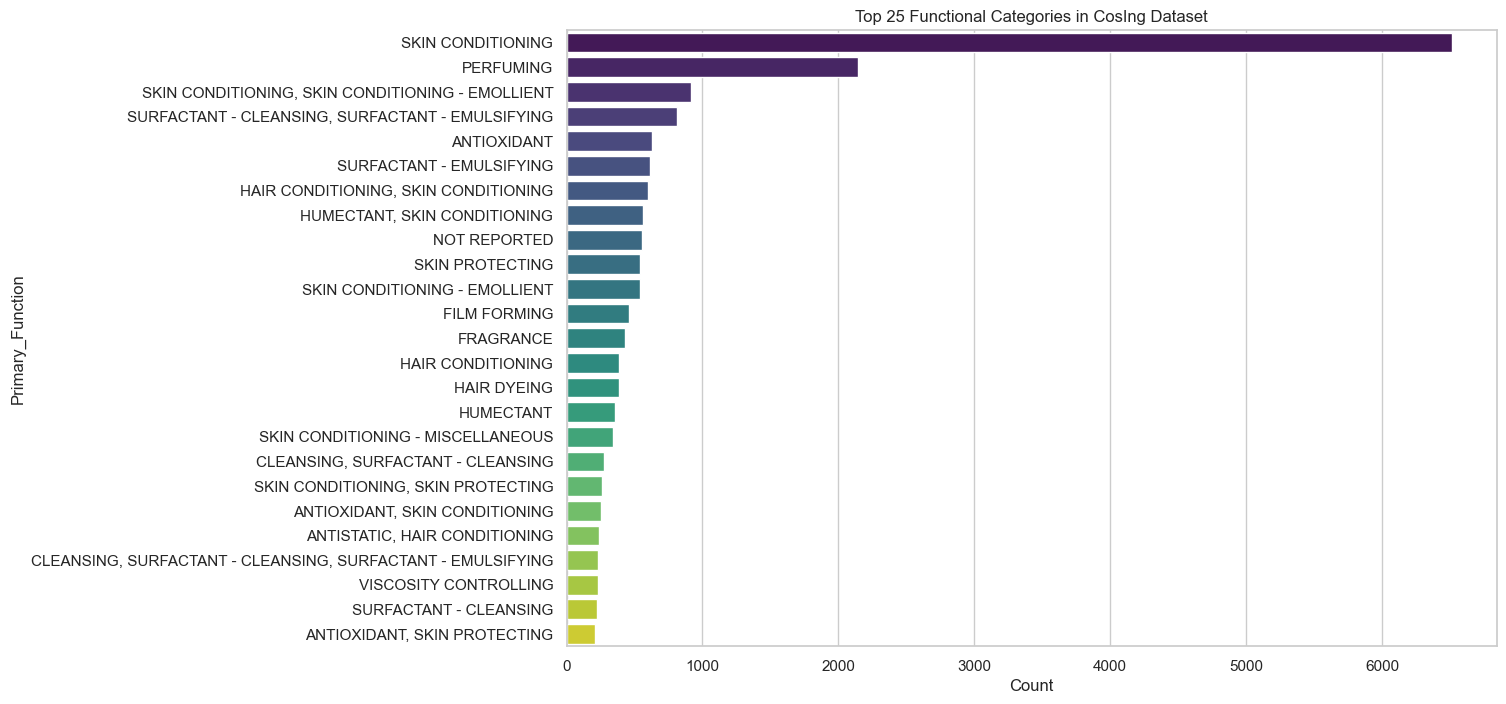

In [3]:
top25 = df['Primary_Function'].value_counts().head(25)
plt.figure(figsize=(12, 8))
sns.barplot(y=top25.index, x=top25.values, palette='viridis')
plt.title('Top 25 Functional Categories in CosIng Dataset')
plt.xlabel('Count')
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()

### Stage 1: Baseline Evaluation
Comparing Logistic Regression, Decision Tree, and Random Forest on the full dataset.

In [4]:
le = LabelEncoder()
y = le.fit_transform(df['Primary_Function'])

tf_n = TfidfVectorizer(max_features=5000, analyzer='char_wb', ngram_range=(2, 5))
tf_d = TfidfVectorizer(max_features=3000, stop_words='english')

X = hstack([tf_n.fit_transform(df['INCI name']), tf_d.fit_transform(df['Description'])])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def evaluate(name, yt, yp):
    return {'Model': name, 'Accuracy': accuracy_score(yt, yp), 'Precision': precision_score(yt, yp, average='weighted', zero_division=0), 'Recall': recall_score(yt, yp, average='weighted', zero_division=0), 'F1 Score': f1_score(yt, yp, average='weighted', zero_division=0)}

print('Training Baseline LR...')
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
r_lr = evaluate('LR', y_test, lr.predict(X_test))

print('Training Baseline DT...')
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
r_dt = evaluate('DT', y_test, dt.predict(X_test))

print('Training Baseline RF-100...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
r_rf = evaluate('RF-100', y_test, rf.predict(X_test))

print('Training Optimized RF-300...')
rf300 = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf300.fit(X_train, y_train)
r_rf300 = evaluate('RF-300', y_test, rf300.predict(X_test))

# Store best all-data metrics
best_all_metrics = r_rf300
best_all_name = 'RF-300'

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [1, 2, 3, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 22, 24, 25, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 53, 54, 55, 56, 57, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 73, 74, 76, 78, 79, 80, 81, 83, 85, 86, 88, 89, 90, 91, 93, 94, 96, 99, 102, 105, 106, 107, 110, 111, 112, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 127, 129, 131, 132, 133, 135, 136, 137, 139, 140, 142, 143, 144, 146, 147, 149, 150, 151, 152, 154, 155, 157, 158, 160, 161, 163, 164, 165, 166, 167, 168, 170, 171, 172, 173, 176, 178, 179, 180, 181, 182, 184, 185, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 202, 203, 204, 205, 206, 207, 208, 209, 210, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 225, 228, 230, 232, 233, 234, 235, 236

### Stage 2: Domain Isolation and Specialized Vectorization
Filtering to skincare-only classes and retraining with fresh features.

In [5]:
skin_care_classes = ['SKIN CONDITIONING', 'ANTIOXIDANT', 'HUMECTANT', 'SKIN PROTECTING', 'ASTRINGENT', 'ANTI-SEBUM', 'ANTI-SEBORRHEIC', 'EXFOLIATING', 'UV ABSORBER', 'MOISTURISING']
df_skin = df[df['Primary_Function'].isin(skin_care_classes)].copy()

le_skin = LabelEncoder()
y_s = le_skin.fit_transform(df_skin['Primary_Function'])

tf_n_s = TfidfVectorizer(max_features=8000, analyzer='char_wb', ngram_range=(2, 6))
tf_d_s = TfidfVectorizer(max_features=6000, stop_words='english')

X_s = hstack([tf_n_s.fit_transform(df_skin['INCI name']), tf_d_s.fit_transform(df_skin['Description'])])
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

print('Training RF-300 on Skincare...')
rf_skin = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_skin.fit(X_tr_s, y_tr_s)
y_pred_s = rf_skin.predict(X_te_s)
r_rf_s = evaluate('RF-300 (Skincare)', y_te_s, y_pred_s)

best_skin_metrics = r_rf_s
best_skin_name = 'RF-300'
y_pred_best_skin = y_pred_s

Training RF-300 on Skincare...


NameError: name 'evaluate' is not defined

### Stage 3: Final Performance Tuning: Class Sparsity Reduction Strategy
Consolidating categories into 3 super-categories to minimize categorical conflict and enhance reliability.

In [6]:
skin_cluster_map = {
    'HUMECTANT': 'Hydration & Conditioning', 'MOISTURISING': 'Hydration & Conditioning', 'SKIN CONDITIONING': 'Hydration & Conditioning',
    'ANTIOXIDANT': 'Environmental Protection', 'SKIN PROTECTING': 'Environmental Protection', 'UV ABSORBER': 'Environmental Protection',
    'ASTRINGENT': 'Active Treatment', 'ANTI-SEBUM': 'Active Treatment', 'ANTI-SEBORRHEIC': 'Active Treatment', 'EXFOLIATING': 'Active Treatment'
}
df_skin['Skin_Cluster'] = df_skin['Primary_Function'].map(skin_cluster_map)

le_focus = LabelEncoder()
y_focus = le_focus.fit_transform(df_skin['Skin_Cluster'])

tf_n_f = TfidfVectorizer(max_features=8000, analyzer='char_wb', ngram_range=(2, 6))
tf_d_f = TfidfVectorizer(max_features=6000, stop_words='english')

X_focus = hstack([tf_n_f.fit_transform(df_skin['INCI name']), tf_d_f.fit_transform(df_skin['Description'])])
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_focus, y_focus, test_size=0.2, random_state=42, stratify=y_focus)

print('Training CSR Strategy Model...')
rf_focus = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_focus.fit(Xf_train, yf_train)
yf_pred = rf_focus.predict(Xf_test)
r_focus = evaluate('RF-300 (CSR Strategy)', yf_test, yf_pred)

Training CSR Strategy Model...


NameError: name 'evaluate' is not defined

### Evaluation and Results Visualization

In [7]:
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Accuracy Progression
stages = ['LR', 'DT', 'RF-100', 'RF-300\n(All Data)', 'RF-300\n(Skincare)', 'RF-300\n(CSR Strategy)']
accs = [r_lr['Accuracy']*100, r_dt['Accuracy']*100, r_rf['Accuracy']*100, r_rf300['Accuracy']*100, r_rf_s['Accuracy']*100, r_focus['Accuracy']*100]
plt.figure(figsize=(14, 6))
bars = plt.bar(stages, accs, color=['#95a5a6','#e74c3c','#f39c12','#3498db','#27ae60','#9b59b6'], edgecolor='black')
for b, v in zip(bars, accs):
    plt.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Accuracy Progression Across Models')
plt.ylim(0, 100)
plt.savefig('accuracy_progression.png', dpi=150)
plt.show()

# 2. Combined ROC Curves
plt.figure(figsize=(12, 10))
n_classes_skin = len(le_skin.classes_)
y_test_bin_skin = label_binarize(y_te_s, classes=range(n_classes_skin))
y_score_skin = rf_skin.predict_proba(X_te_s)
colors_skin = plt.cm.tab10(np.linspace(0, 1, n_classes_skin))
for i in range(n_classes_skin):
    fpr, tpr, _ = roc_curve(y_test_bin_skin[:, i], y_score_skin[:, i])
    plt.plot(fpr, tpr, color=colors_skin[i], lw=1, linestyle='--', label=f'Skincare: {le_skin.classes_[i]} (AUC={auc(fpr, tpr):.2f})')

n_classes_focus = len(le_focus.classes_)
y_test_bin_focus = label_binarize(yf_test, classes=range(n_classes_focus))
y_score_focus = rf_focus.predict_proba(Xf_test)
colors_focus = ['#e74c3c', '#2ecc71', '#9b59b6']
for i in range(n_classes_focus):
    fpr, tpr, _ = roc_curve(y_test_bin_focus[:, i], y_score_focus[:, i])
    plt.plot(fpr, tpr, color=colors_focus[i], lw=3, label=f'CSR Strategy: {le_focus.classes_[i]} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.legend(loc='lower right', fontsize=8)
plt.title('Combined ROC Curves')
plt.savefig('roc_final.png', dpi=150)
plt.show()

NameError: name 'r_lr' is not defined